In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.style.use("default")
sns.set_context("notebook")

LOADIND THE DATASET

In [7]:
df=pd.read_csv(r"C:\Users\minhaj\Downloads\Salary_Dataset_DataScienceLovers.csv")

In [14]:
df.shape

(22770, 8)

In [28]:
df.describe(include='all')

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22770,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11261,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22770 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


DATA CLEANING

In [30]:
df.isnull().sum()

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [37]:
df.drop_duplicates()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [ ]:
#REMOVE OUTLIERS

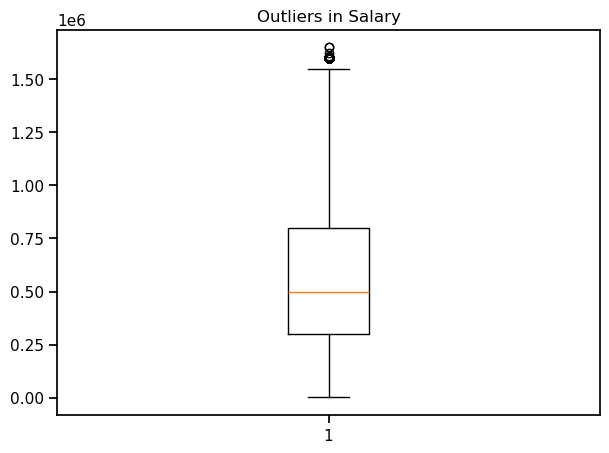

In [176]:
plt.figure(figsize=(7,5))
plt.boxplot(x=df['Salary'])
plt.title('Outliers in Salary')
plt.show()

In [ ]:
#Removing the outliers using IQR(Interquartile Range)

In [177]:
Q1=df['Salary'].quantile(0.25)
Q3=df['Salary'].quantile(0.75)
IQR=Q3-Q1

In [178]:
lower_limit=Q1-1.5*IQR
upper_limit=Q2+1.5*IQR


In [181]:
df=df[(df['Salary']>=lower_limit) & (df['Salary']<=upper_limit)]


In [182]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [168]:
#Univariate Analysis

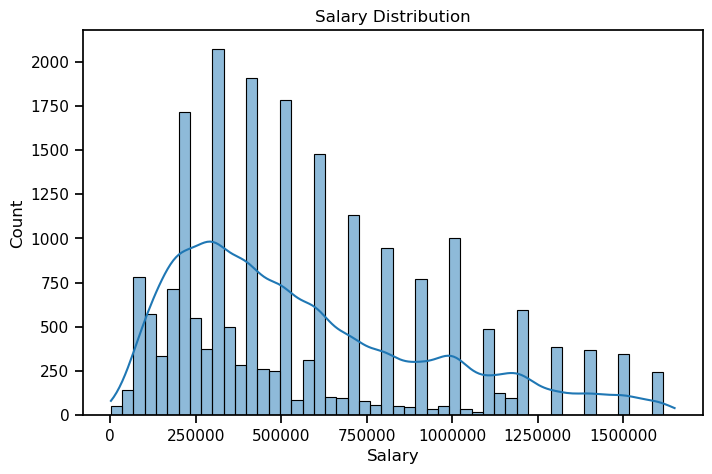

In [169]:
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'],bins=50,kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.ticklabel_format(style='plain',axis='x')
plt.show()

In [170]:
#BUSINESS QUESTIONS

In [171]:
#WHICH JOB ROLES HAS THE HIGHEST SALARY

In [172]:
df.groupby('Job Roles')['Salary'].mean().sort_values(ascending=False)

Job Roles
Database    721700.266667
SDE         665860.534273
Mobile      617788.018433
IOS         601729.499024
Backend     547170.279288
Frontend    512154.482221
Android     490062.467303
Java        483368.437989
Testing     467473.941657
Python      453234.918455
Web         392554.089069
Name: Salary, dtype: float64

In [173]:
#WHICH JOB ROLES HAS THE HIGHEST SALARY(TOP 10)

In [174]:
high=df.groupby('Job Roles')['Salary'].mean().sort_values(ascending=False).head(10)

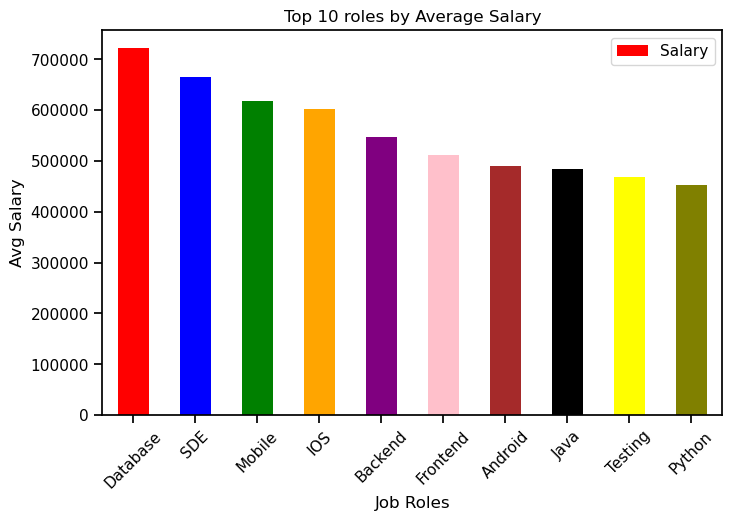

In [175]:
plt.figure(figsize=(8,5))
colors=['red', 'blue', 'green', 'orange', 'purple','pink','brown','black','yellow','olive']

rect=high.plot(kind='bar',color=colors)
plt.ylabel('Avg Salary')
plt.title('Top 10 roles by Average Salary')
plt.legend()

plt.xticks(rotation=45)
plt.show()

In [ ]:
#Which cities offer highest salaries

In [183]:
high_cities=df.groupby('Location')['Salary'].mean().sort_values(ascending=False).head(10)

In [184]:
high_cities

Location
Mumbai            724227.877301
Bangalore         583329.650224
Pune              568612.816000
Jaipur            566153.846154
New Delhi         553584.092254
Kolkata           552618.181818
Hyderabad         550758.314176
Kerala            514965.735849
Chennai           512052.705882
Madhya Pradesh    497530.378378
Name: Salary, dtype: float64

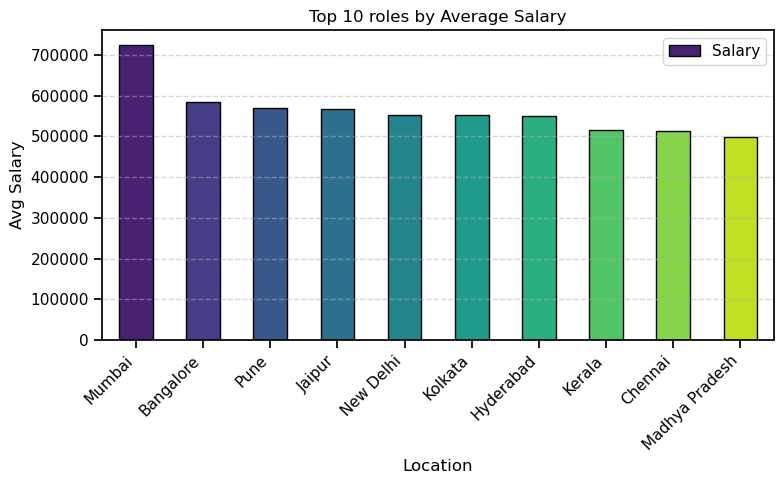

In [187]:
plt.figure(figsize=(8,5))
colors=sns.color_palette("viridis",len(high_cities))

high_cities.plot(kind='bar',color=colors,edgecolor='black')
plt.ylabel('Avg Salary')
plt.title('Top cities by Average Salary')
plt.legend()

plt.xticks(rotation=45,ha='right')
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

In [220]:
df[(df['Location']=='New Delhi') & (df['Rating']==5)].sort_values(by='Salary',ascending= False).head(5)[['Location','Company Name','Salary']]

,Location,Company Name,Salary
1888,New Delhi,Trillbit,1500000
6750,New Delhi,Hapramp,1500000
17488,New Delhi,The Art of Mike Mignola,1500000
8284,New Delhi,Silicon Valley Recycling,1400000
17351,New Delhi,Parth Universal,1300000


In [221]:
df[(df['Location']=='New Delhi') & (df['Rating']==5)].sort_values(by='Salary',ascending= False).tail(5)[['Location','Company Name','Salary']]

,Location,Company Name,Salary
8008,New Delhi,Rabbler,100000
1969,New Delhi,WorkingNation,84000
2334,New Delhi,Hopin (India),60000
17524,New Delhi,Star Catalysts,60000
18680,New Delhi,Atom 8,60000


In [ ]:
#Which job title has the highes salary reported

In [225]:
df.groupby('Job Title')['Salaries Reported'].count().sort_values(ascending=False).head(1)

Job Title
Software Development Engineer    2184
Name: Salaries Reported, dtype: int64

In [ ]:
#

In [237]:
filtered=df[df['Salaries Reported']>=20]

In [240]:
filtered

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
8790,3.9,Tata Consultancy Services,Java Developer,200000,30,Chennai,Full Time,Java
8977,3.8,Cognizant Technology Solutions,Senior Java Developer,200000,35,Chennai,Full Time,Java
8978,3.9,Tata Consultancy Services,Senior Java Developer,300000,30,Chennai,Full Time,Java
8979,3.9,Tata Consultancy Services,Junior Java Developer,200000,30,Chennai,Full Time,Java
9688,3.9,Tata Consultancy Services,Java Developer,200000,43,Hyderabad,Full Time,Java
...,...,...,...,...,...,...,...,...
21762,3.8,CGI,Senior Test Engineer,400000,21,Bangalore,Full Time,Testing
21763,4.1,IBM,Test Automation Engineer,400000,21,Bangalore,Full Time,Testing
21764,3.7,SLK Group,Software Test Engineer,300000,20,Bangalore,Full Time,SDE
21765,4.3,Cisco Systems,Software Test Engineer,700000,20,Bangalore,Full Time,SDE


In [242]:
filtered.groupby('Company Name')['Salary'].mean().sort_values(ascending=False).head(5)

Company Name
Expedia Group     1350000.0
Nokia             1200000.0
Amadeus           1200000.0
Alcatel-Lucent    1000000.0
Ola               1000000.0
Name: Salary, dtype: float64

In [244]:
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [246]:
df.corr(numeric_only=True)


,Rating,Salary,Salaries Reported
Rating,1.000000,0.025937,-0.013309
Salary,0.025937,1.000000,-0.022951
Salaries Reported,-0.013309,-0.022951,1.000000


In [249]:
float(df['Rating'].corr(df['Salary']))

0.025936917862653706

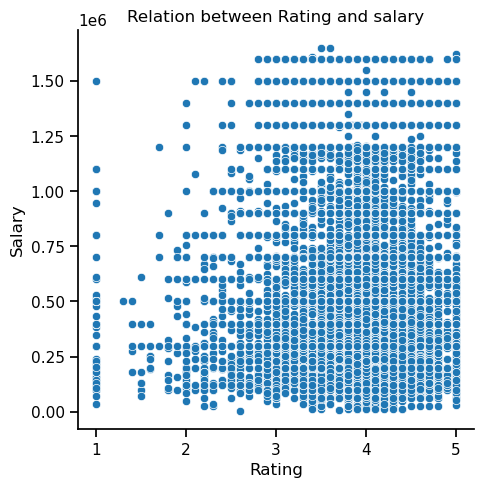

In [254]:
sns.relplot(x='Rating',y='Salary',data=df)
plt.title('Relation between Rating and salary')

plt.show()

In [ ]:
#Does Employemnt Status effect Salary

In [256]:
df.groupby('Employment Status')['Salary'].mean().sort_values(ascending=False)

Employment Status
Full Time     592361.164957
Contractor    512110.795367
Intern        339560.730751
Trainee       324303.030303
Name: Salary, dtype: float64

C:\Users\minhaj\AppData\Local\Temp\ipykernel_18944\267055507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Employment Status',y='Salary',data=df,palette=colors)


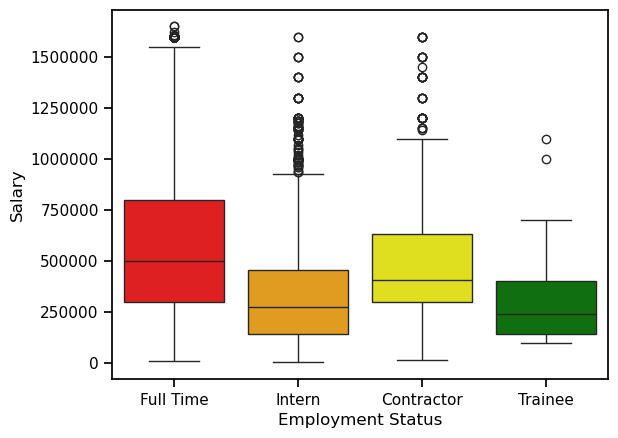

In [262]:
colors=['red','orange','yellow','green']
sns.boxplot(x='Employment Status',y='Salary',data=df,palette=colors)
plt.ticklabel_format(style='plain',axis='y')
plt.show()

In [ ]:
#Most common job roles

In [265]:
top_10_roles=df['Job Roles'].value_counts().head(10)

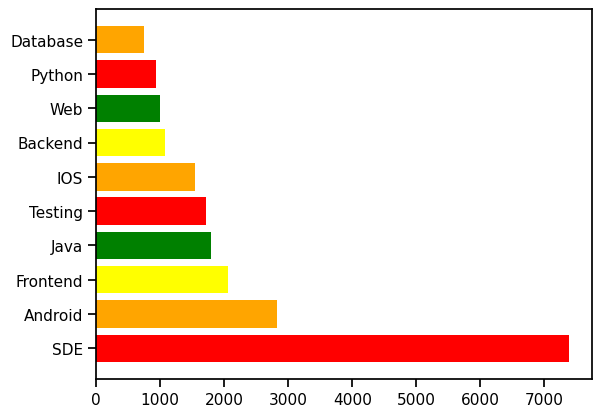

In [267]:
sns.color_palette=('hsv',len(top_10_roles))
plt.barh(top_10_roles.index,top_10_roles.values,color=colors)
plt.show()


In [295]:
rating_salary = df.groupby('Rating', as_index=False)['Salary'].mean().reset_index()
      

In [296]:
rating_salary

,index,Rating,Salary
0,0,1.00,399971.500000
1,1,1.30,500000.000000
2,2,1.40,331200.000000
3,3,1.50,241000.000000
4,4,1.60,262285.714286
5,5,1.70,750000.000000
6,6,1.80,330333.333333
7,7,1.90,438666.666667
8,8,2.00,437481.481481
9,9,2.10,465866.666667


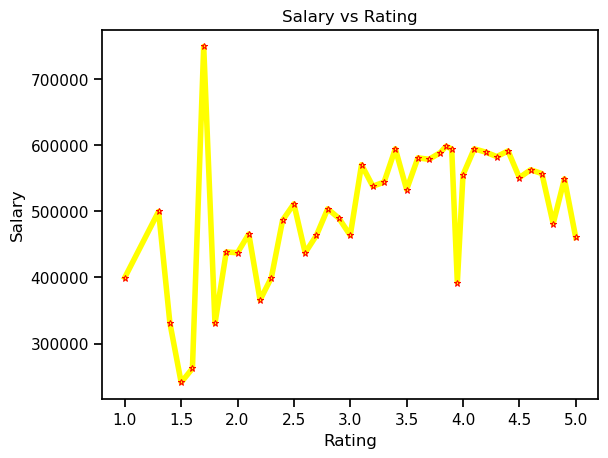

In [313]:
sns.lineplot(x='Rating',y='Salary',data=rating_salary,marker='*',markersize=5,linewidth=4,markeredgecolor='red',color='yellow')
plt.title('Salary vs Rating')
plt.show()

In [ ]:
#SMALL DASHBOARD

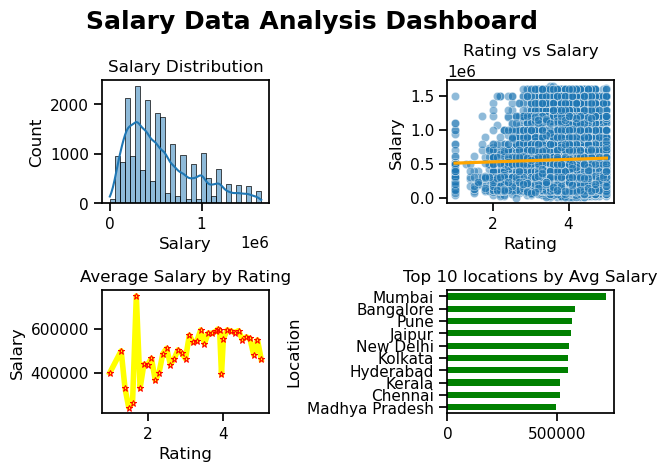

In [326]:
rating_salary = df.groupby('Rating', as_index=False)['Salary'].mean().reset_index()
high_cities=df.groupby('Location')['Salary'].mean().sort_values(ascending=False).head(10)

plt.subplot(2,2,1)
sns.histplot(df['Salary'],bins=30,kde=True)
plt.title("Salary Distribution")

plt.subplot(2,2,2)
sns.scatterplot(x='Rating',y='Salary',data=df,alpha=0.5)
sns.regplot(x='Rating',y='Salary',data=df,scatter=False,color='orange')
plt.title('Rating vs Salary')

plt.subplot(2,2,3)
sns.lineplot(x='Rating',y='Salary',data=rating_salary,marker='*',markersize=5,linewidth=4,markeredgecolor='red',color='yellow')
plt.title('Average Salary by Rating')

plt.subplot(2,2,4)
high_cities.sort_values().plot(kind='barh',color='green')
plt.title('Top 10 locations by Avg Salary')

plt.suptitle('Salary Data Analysis Dashboard',fontsize=18,fontweight='bold')
plt.tight_layout()
plt.show()